# Explore stratification across sea ice formation period

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [116]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36139")
client

<Client: 'tcp://127.0.0.1:36139' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst - 1000 # minus 1000 to get potential density

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

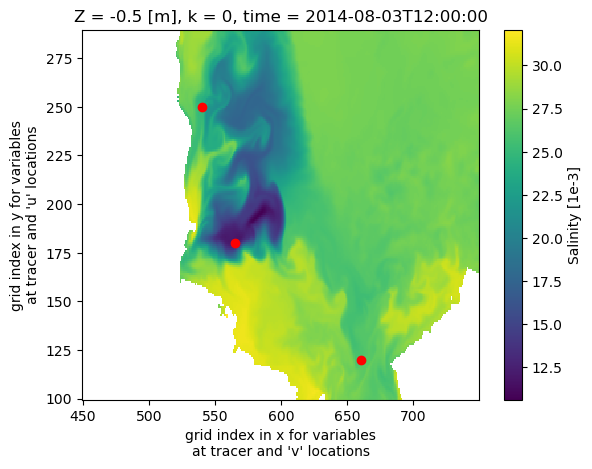

In [9]:
# plot Beaufort Sea area
salt_day.isel(k=0,i=slice(450,750),j=slice(100,290),time=200).plot();
plt.scatter(565,180,c='r');
plt.scatter(540,250,c='r');
plt.scatter(660,120,c='r');

### Determine dates when SI > 0, 15, and 50% for three points and plot profiles

In [10]:
i_west=540
j_west=250

i_plume=565
j_plume=180

i_east=660
j_east=120

In [41]:
ice_grid_west = ice_day.isel(i=i_west, j=j_west).sel(time=slice("2019-09-15","2019-12-30")).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
ice_grid_plume = ice_day.isel(i=i_plume, j=j_plume).sel(time=slice("2019-09-15","2019-12-30")).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
ice_grid_east = ice_day.isel(i=i_east, j=j_east).sel(time=slice("2019-09-15","2019-12-30")).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")

In [42]:
# WEST
print("\nWest of Mackenzie River plume")
print(ice_grid_west.sel(time=ice_grid_west>0).time.values[0])
print(ice_grid_west.sel(time=ice_grid_west>=15).time.values[0])
print(ice_grid_west.sel(time=ice_grid_west>=50).time.values[0])

# PLUME
print("\nIn Mackenzie River plume")
print(ice_grid_plume.sel(time=ice_grid_plume>0).time.values[0])
print(ice_grid_plume.sel(time=ice_grid_plume>=15).time.values[0])
print(ice_grid_plume.sel(time=ice_grid_plume>=50).time.values[0])

# EAST
print("\nNortheast of Mackenzie River plume")
print(ice_grid_east.sel(time=ice_grid_east>0).time.values[0])
print(ice_grid_east.sel(time=ice_grid_east>=15).time.values[0])
print(ice_grid_east.sel(time=ice_grid_east>=50).time.values[0])


West of Mackenzie River plume
2019-11-08T12:00:00.000000000
2019-11-13T12:00:00.000000000
2019-11-14T12:00:00.000000000

In Mackenzie River plume
2019-10-09T12:00:00.000000000
2019-10-26T12:00:00.000000000
2019-11-10T12:00:00.000000000

Northeast of Mackenzie River plume
2019-10-13T12:00:00.000000000
2019-10-14T12:00:00.000000000
2019-10-29T12:00:00.000000000


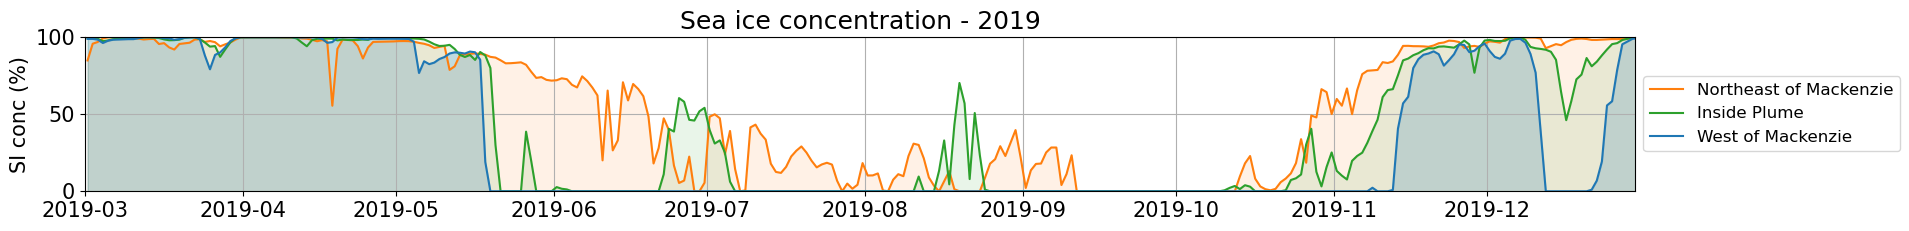

In [30]:
plt.rcParams['font.size'] = 15

ice_grid_west_timeseries = ice_day.isel(i=i_west, j=j_west).sel(time=slice("2019-03-01","2019-12-30"))
ice_grid_plume_timeseries = ice_day.isel(i=i_plume, j=j_plume).sel(time=slice("2019-03-01","2019-12-30"))
ice_grid_east_timeseries = ice_day.isel(i=i_east, j=j_east).sel(time=slice("2019-03-01","2019-12-30"))

fig, ax = plt.subplots(figsize=[20, 2])

ax.plot(ice_grid_east_timeseries.time, ice_grid_east_timeseries, label="Northeast of Mackenzie",color='tab:orange')
ax.fill_between(ice_grid_east_timeseries.time, ice_grid_east_timeseries, 0, alpha=0.1,color='tab:orange')

ax.plot(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, label="Inside Plume",color='tab:green')
ax.fill_between(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, 0, alpha=0.1,color='tab:green')

ax.plot(ice_grid_west_timeseries.time, ice_grid_west_timeseries, label="West of Mackenzie",color='tab:blue')
ax.fill_between(ice_grid_west_timeseries.time, ice_grid_west_timeseries, 0, alpha=0.2,color='tab:blue')

ax.grid()
ax.set_ylim(0, 100)
ax.set_xlim([np.datetime64("2019-03-01"),np.datetime64("2019-12-30")])
ax.legend(loc='upper left', fontsize=12, bbox_to_anchor=[1, 0.8])
ax.set_title("Sea ice concentration - 2019")
ax.set_xlabel("")
ax.set_ylabel("SI conc (%)")

plt.show()

In [37]:
import matplotlib.dates as mdates

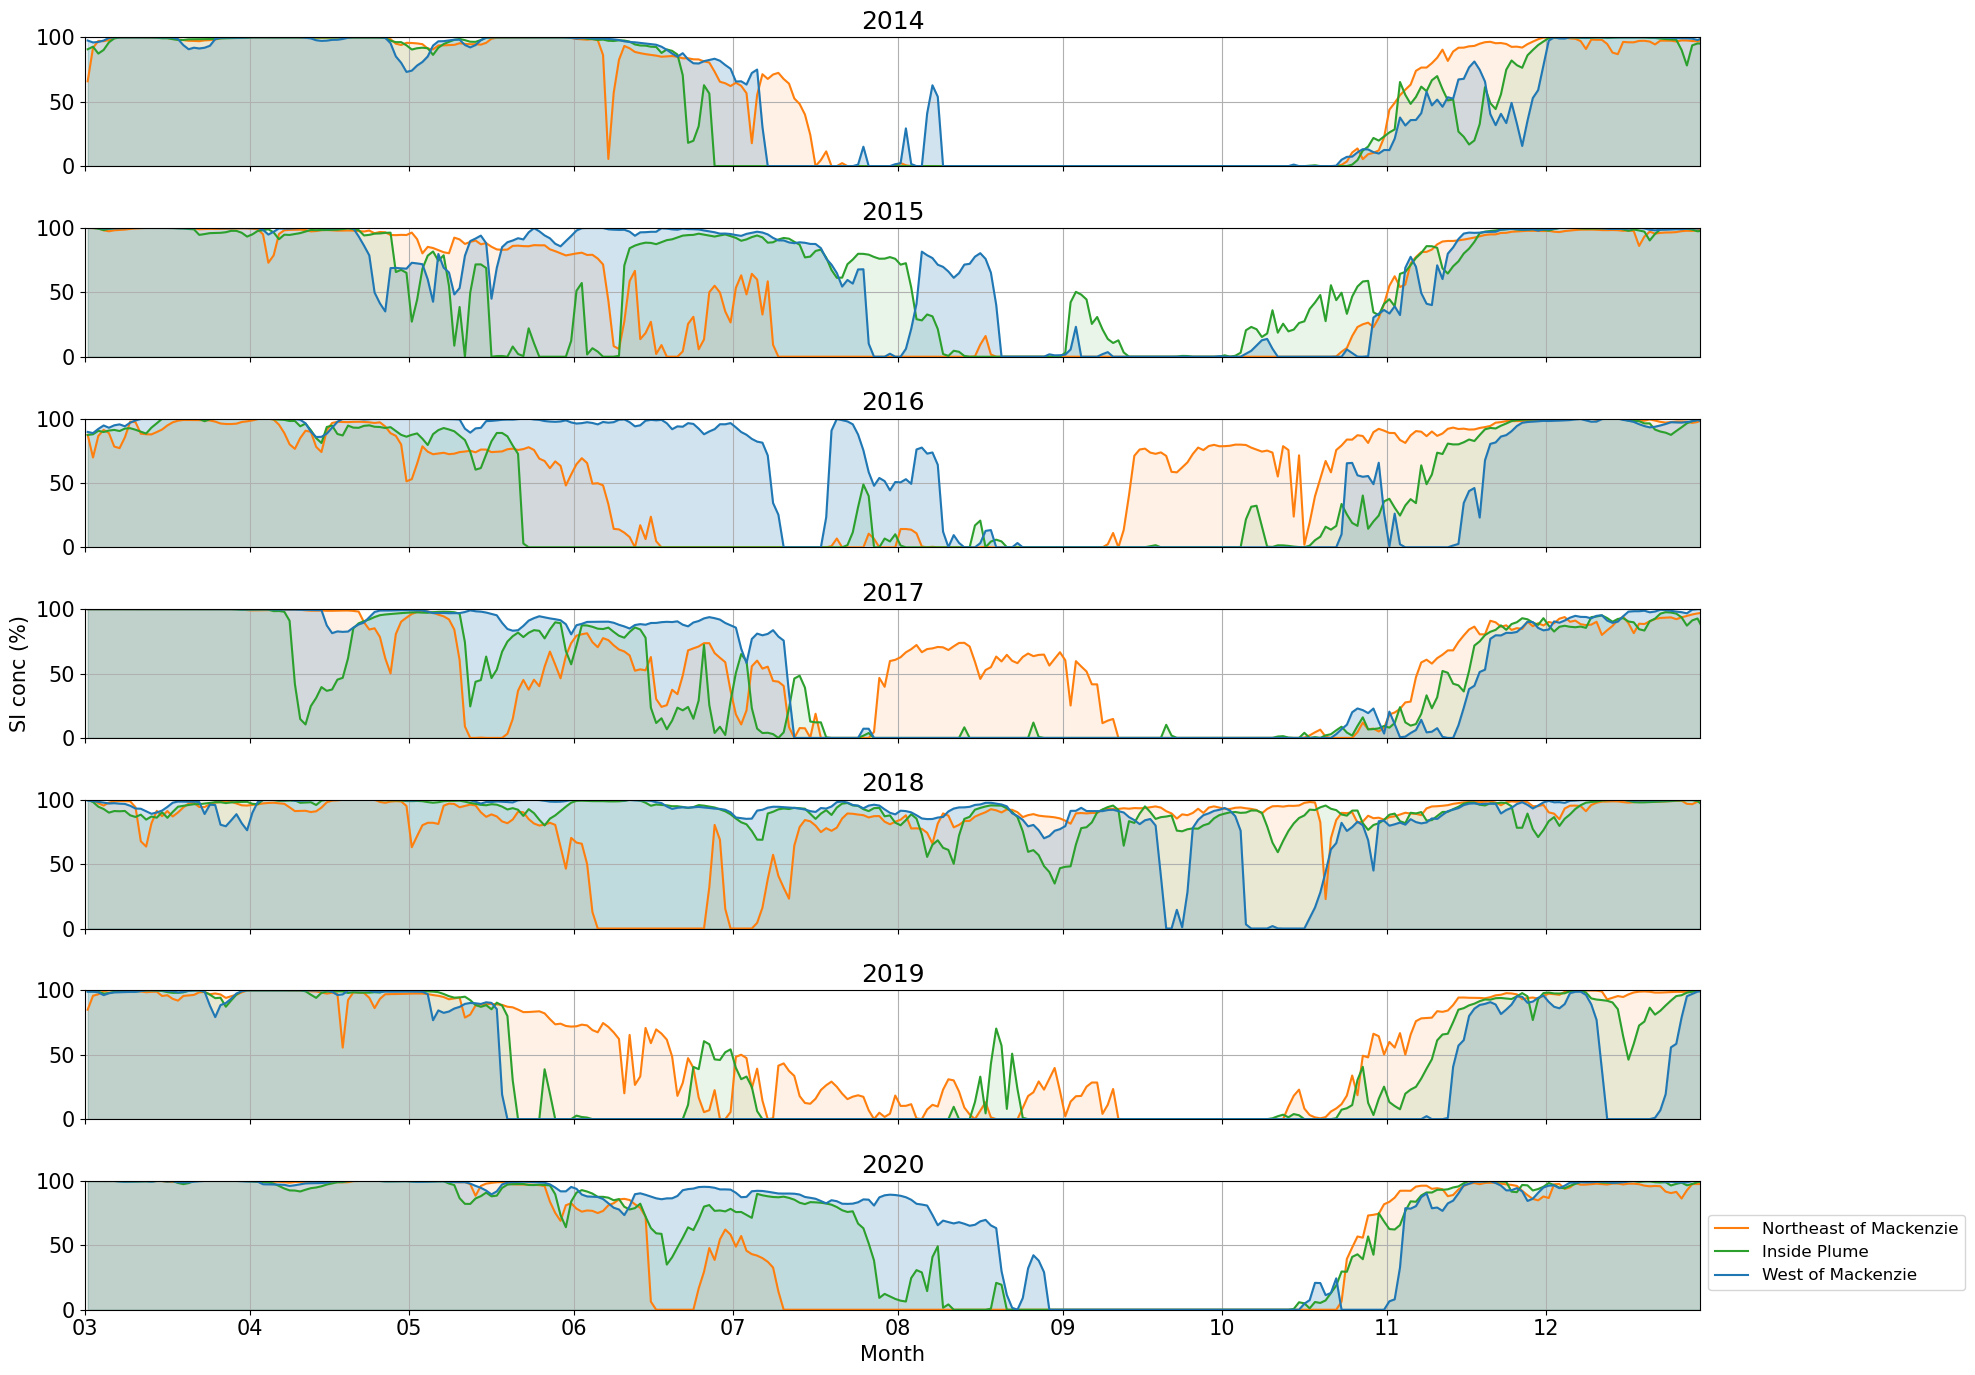

In [45]:
plt.rcParams['font.size'] = 15

years = np.arange(2014, 2021)  # 2014 to 2020

fig, axes = plt.subplots(nrows=len(years), figsize=(20, 14))

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    start_date = f"{year}-03-01"
    end_date = f"{year}-12-30"

    ice_grid_west_timeseries = ice_day.isel(i=i_west, j=j_west).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
    ice_grid_plume_timeseries = ice_day.isel(i=i_plume, j=j_plume).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
    ice_grid_east_timeseries = ice_day.isel(i=i_east, j=j_east).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")

    # Plot each region's time series with shading
    ax.plot(ice_grid_east_timeseries.time, ice_grid_east_timeseries, label="Northeast of Mackenzie", color='tab:orange')
    ax.fill_between(ice_grid_east_timeseries.time, ice_grid_east_timeseries, 0, alpha=0.1, color='tab:orange')

    ax.plot(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, label="Inside Plume", color='tab:green')
    ax.fill_between(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, 0, alpha=0.1, color='tab:green')

    ax.plot(ice_grid_west_timeseries.time, ice_grid_west_timeseries, label="West of Mackenzie", color='tab:blue')
    ax.fill_between(ice_grid_west_timeseries.time, ice_grid_west_timeseries, 0, alpha=0.2, color='tab:blue')

    ax.grid()
    ax.set_ylim(0, 100)
    ax.set_xlim([np.datetime64(start_date), np.datetime64(end_date)])

    # Remove tick labels except for the last (bottom) subplot
    if i < len(years) - 1:
        ax.set_xticklabels([])  # Hide tick labels for all but last subplot

    ax.set_ylabel("SI conc (%)" if i == len(years) // 2 else "")  # Only middle subplot gets a label

    # Title for each subplot
    ax.set_title(f"{year}")

# Format the x-axis of the last subplot
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks at the start of each month
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m"))  # Label ticks with month number (1-12)

# Add legend only to the last subplot
axes[-1].legend(loc='upper left', fontsize=12, bbox_to_anchor=[1, 0.8])

plt.xlabel("Month")
plt.tight_layout()
plt.show()

#### Plot profiles for these days

In [127]:
def plot_profile(date, theta_day, salt_day, density_day, HH_grid, i=565, j=180):
    """
    Plots temperature, salinity, and density profiles for a single date with key density layer markers.
    
    Parameters:
    - date: Date to plot (must be a string in 'YYYY-MM-DD' format).
    - theta_day: Dataset containing temperature values.
    - salt_day: Dataset containing salinity values.
    - density_day: Dataset containing density values.
    - HH_grid: Grid object containing `rAc`, `drF`, and `hFacC` for volume calculations.
    - i, j: Grid indices to extract data from (default: 565, 180).
    """
    # Create figure and subplots
    plt.rcParams['font.size'] = 14
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6, 6], sharey=True)
    
    # Extract data for the given date
    theta = theta_day.sel(time=date).isel(i=i, j=j, time=0)
    salt = salt_day.sel(time=date).isel(i=i, j=j, time=0)
    density = density_day.sel(time=date).isel(i=i, j=j, time=0)
    
    # Compute MLD
    density_select = density_day.isel(i=i, j=j).sel(time=date)
    rho_surf = density_select.isel(k=0)  # Near-surface density
    density_threshold = 0.1  # kg m^-3
    threshold = rho_surf + density_threshold
    density_minus_threshold = abs(density_select - threshold)
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    MLD = density_select.isel(k=threshold_idx.compute()).Z.values.item()
    
    # Calculate grid volume
    grid_volume = HH_grid.rAc * HH_grid.drF * HH_grid.hFacC
    rho = density_day.sel(time=date).isel(i=i, j=j, time=0)
    vol = grid_volume.isel(i=i, j=j)
    
    # UPPER - Calculate surface density (upper 5 grid cells)
    rho_upper = rho.isel(k=slice(0,5))
    vol_upper = vol.isel(k=slice(0,5))
    rho_avg_upper = (rho_upper * vol_upper).sum(dim=('k')).compute() / vol_upper.sum()
    
    # DEEP - Calculate deep density (3 grid cells from ~39 to 52)
    rho_deep = rho.isel(k=slice(14,17))
    vol_deep = vol.isel(k=slice(14,17))
    rho_avg_deep = (rho_deep * vol_deep).sum(dim=('k')).compute() / vol_deep.sum()
    
    # Calculate surface density deviation
    delta_rho = rho_avg_deep - rho_avg_upper
    
    # Create a scaled depth coordinate between 0 and 1
    scaled_dens_coord = (rho - rho_avg_upper) / delta_rho
    
    SL_mask = scaled_dens_coord < 0.2
    PC_mask = (scaled_dens_coord >= 0.2) & (scaled_dens_coord <= 0.8)
    DW_mask = scaled_dens_coord > 0.8
    
    SL_bottom_depth = HH_grid.Z.where(SL_mask.compute(), drop=True).min().values
    DW_upper_depth = HH_grid.Z.where(DW_mask.compute(), drop=True).max().values
    
    # Plot temperature profile
    theta.plot(ax=ax1, y='Z', color='tab:blue', marker='.', linestyle='solid')
    ax1.axhline(y=MLD, linewidth=2, color='tab:green', linestyle='solid', label="MLD")
    ax1.tick_params(axis='x', colors='tab:blue')
    ax1.legend(fontsize=11,loc='lower left')
    
    # Add salinity profile as a secondary axis
    ax1_sec = ax1.twiny()
    salt.plot(ax=ax1_sec, y='Z', color='tab:red', marker='.', linestyle='solid')
    ax1_sec.tick_params(axis='x', colors='tab:red')
    
    # Plot density profile
    density.plot(ax=ax2, y='Z', color='black', marker='.', linestyle='solid')
    ax2.axhline(y=SL_bottom_depth, color='tab:orange', linewidth=1.5, label="Bottom of\nsurface layer")
    ax2.axhline(y=DW_upper_depth, color='tab:orange', linewidth=1.5, linestyle='dashed', label="Bottom of\npycnocline")
    ax2.legend(fontsize=11,loc='lower left')
    
    # Formatting axes
    for ax in (ax1, ax1_sec, ax2):
        ax.set_ylim(-60, 3)
        ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
        ax.set_title("")
    
    # # west of plume
    # ax1.set_xlim(-2,5)
    # ax1_sec.set_xlim(28,32.5)
    # ax2.set_xlim(23,25.61)
    
    # # inside plume
    # ax1.set_xlim(-2,5.2)
    # ax1_sec.set_xlim(5,35)
    # ax2.set_xlim(5,26)
    
    # northeast of plume
    ax1.set_xlim(-2,5)
    ax1_sec.set_xlim(25,32)
    ax2.set_xlim(22,26)
    
    # Add labels
    ax1.set_xlabel("Temp ($\degree$C)", color='tab:blue')
    ax1_sec.set_xlabel("Salinity (g/kg)", color='tab:red')
    ax1.set_ylabel("Depth (m)")
    ax2.set_ylabel("")
    ax2.set_xlabel("Density (kg/m³)")
    
    # Add title
    fig.suptitle(f"Grid cell [i={i}, j={j}]\n{date}", fontsize=14, y=1.05)
    
    # Show plot
    plt.show()

#### West of Mackenzie

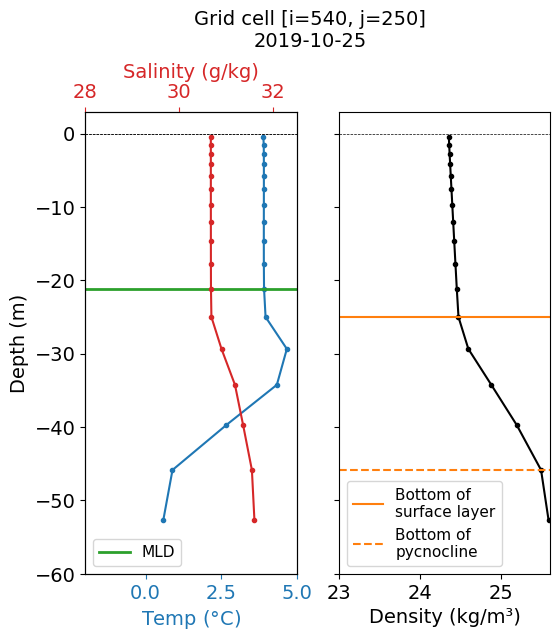

In [93]:
# 14 days before SI>0
plot_profile("2019-10-25", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

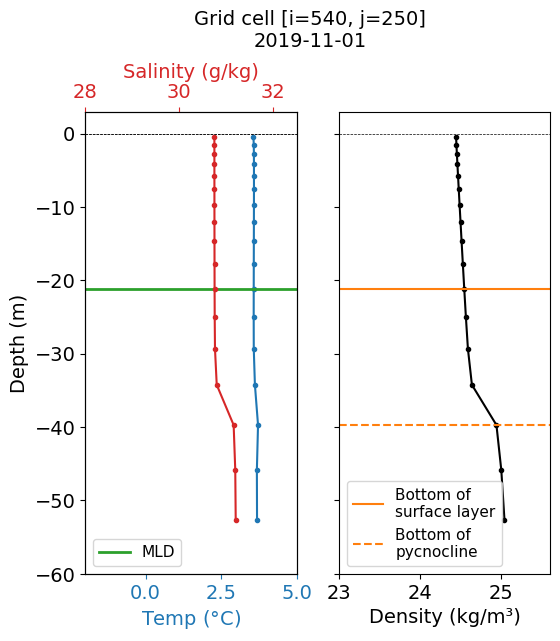

In [94]:
# 7 days before SI>0
plot_profile("2019-11-01", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

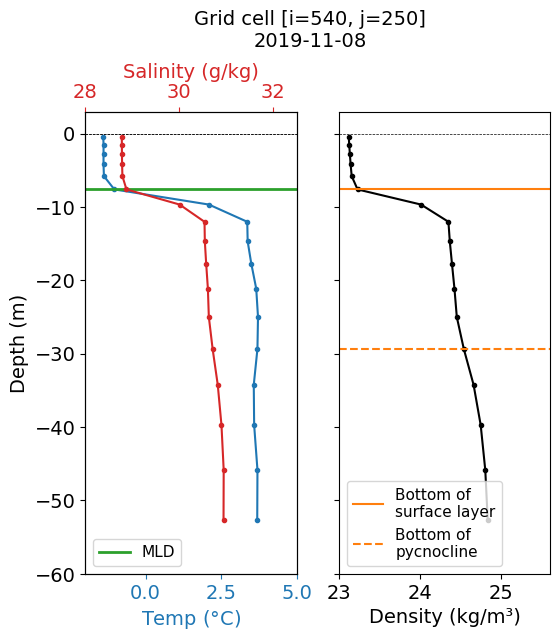

In [95]:
# SI>0
plot_profile("2019-11-08", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

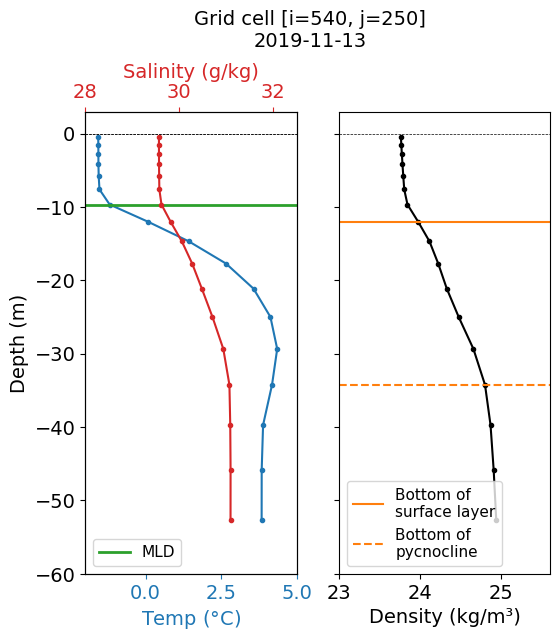

In [96]:
# SI>=15
plot_profile("2019-11-13", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

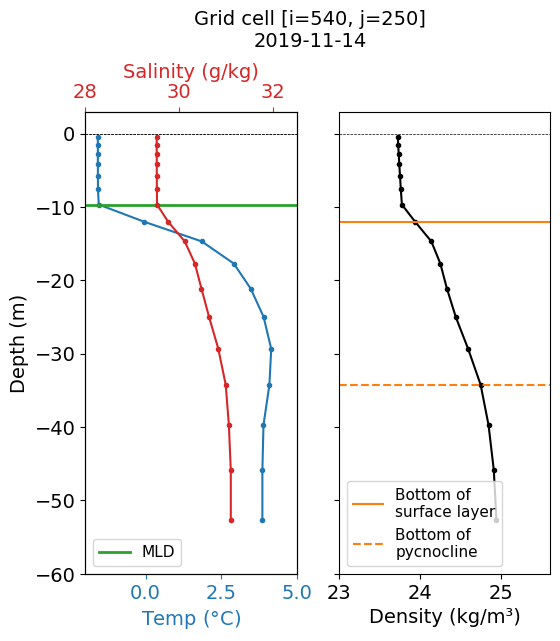

In [97]:
# SI>=50
plot_profile("2019-11-14", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

#### Within Mackenzie

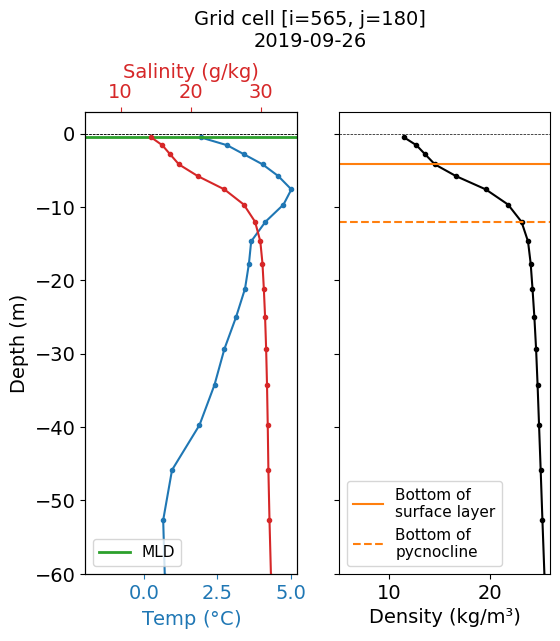

In [113]:
# 14 days before SI>0
plot_profile("2019-09-26", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

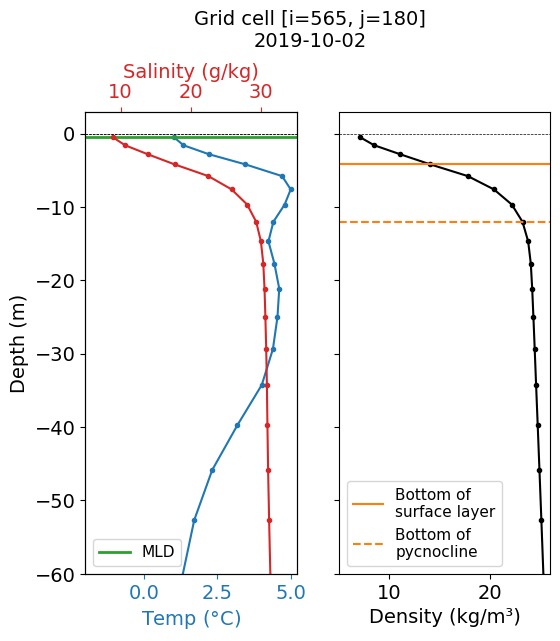

In [114]:
# 7 days before SI>0
plot_profile("2019-10-02", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

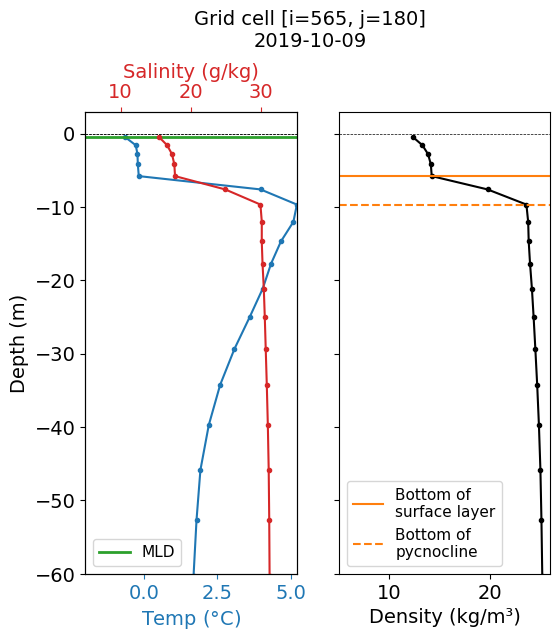

In [115]:
# SI>0
plot_profile("2019-10-09", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

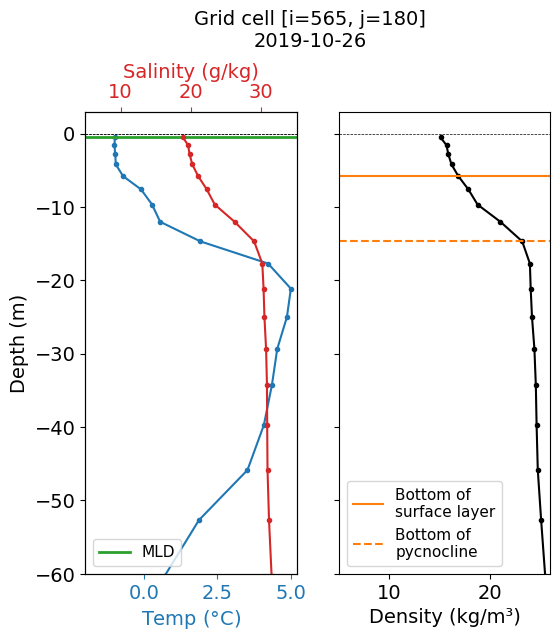

In [116]:
# SI>=15%
plot_profile("2019-10-26", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

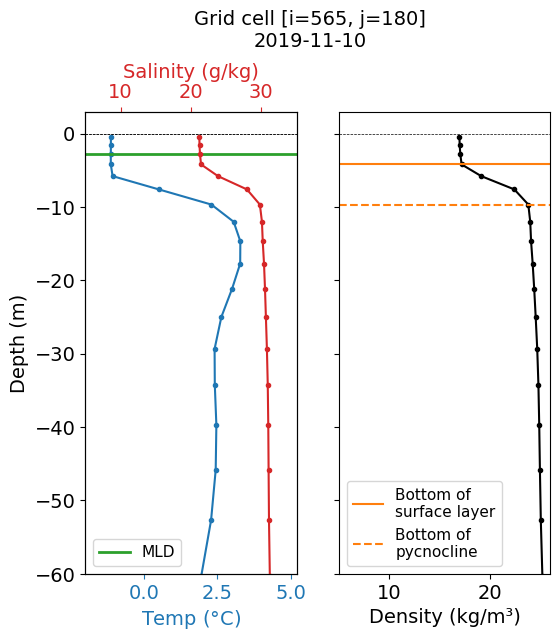

In [117]:
# SI>=50%
plot_profile("2019-11-10", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

#### NE of Mackenzie

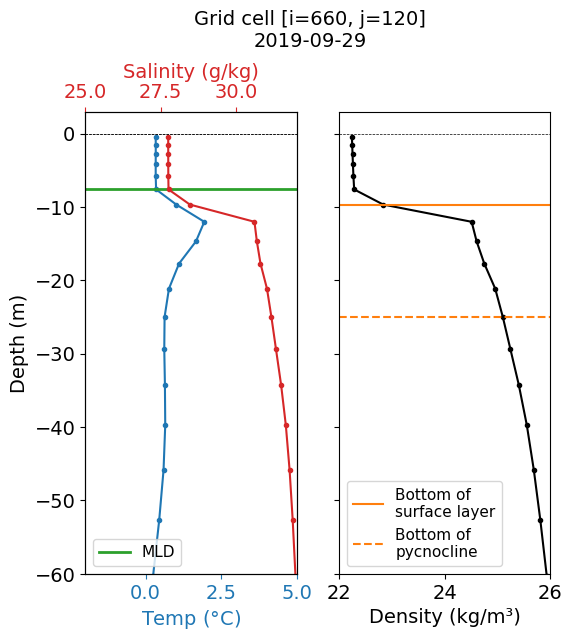

In [128]:
# 14 days before SI>0
plot_profile("2019-09-29", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

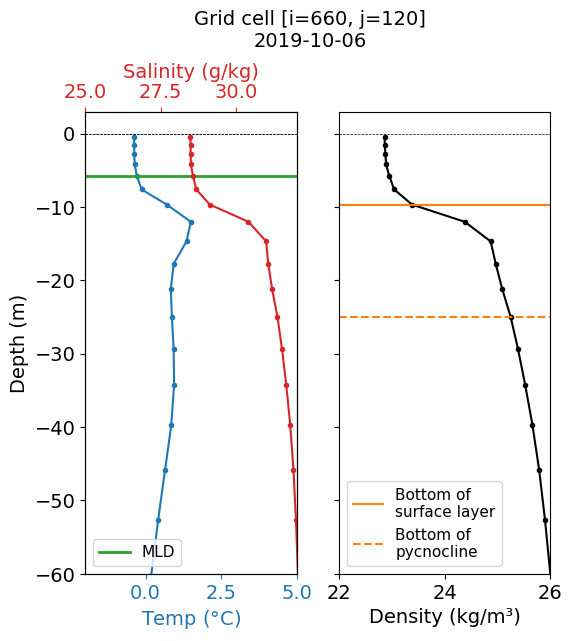

In [129]:
# 7 days before SI>0
plot_profile("2019-10-06", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

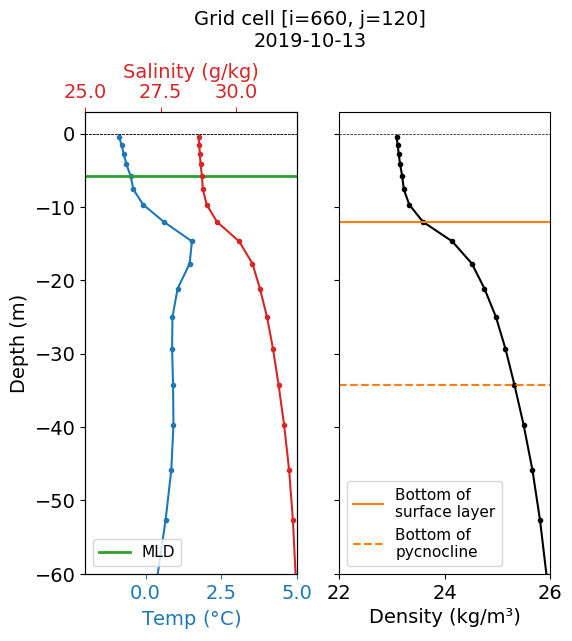

In [130]:
# SI>0
plot_profile("2019-10-13", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

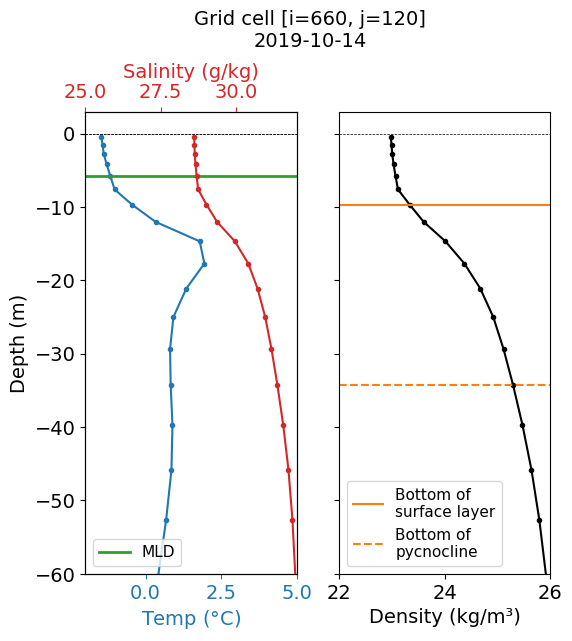

In [131]:
# SI>=15%
plot_profile("2019-10-14", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

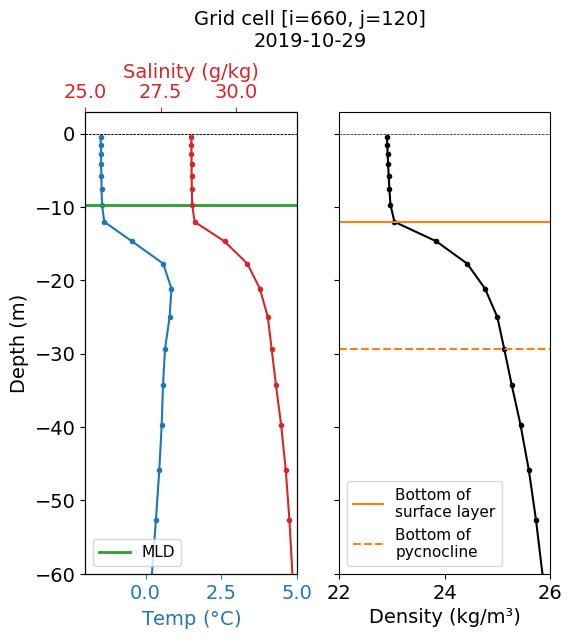

In [132]:
# SI>=50%
plot_profile("2019-10-29", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

## Calculate OHC time series in surface layer and pycnocline

#### Using % total density difference approach

In [57]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
        salinity (array): salinity (PSU)
        temperature (array): temperature (°C)
        depth (array): depth values (m, negative downward)
        lon (float): longitude for SA calculation
        lat (float): latitude for pressure calculation
    
    Returns:
        cp (array): Specific heat capacity (J/kg/degC) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [62]:
def compute_density_masks(density_gridcell, vol_gridcell, upper_k=slice(0, 5), deep_k=slice(14, 17)):
    """
    Compute scaled density coordinate masks based on surface and deep density averages.

    Parameters:
    -----------
    density_gridcell : xarray.DataArray
        Density values at each depth level.
    vol_gridcell : xarray.DataArray
        Volume values corresponding to density grid cells.
    upper_k : slice, optional
        Depth index range for surface layer (default: first 5 layers).
    deep_k : slice, optional
        Depth index range for deep layer (default: 14th-17th layers).

    Returns:
    --------
    tuple of xarray.DataArray:
        - SL_mask : Surface Layer mask (scaled_dens_coord < 0.2)
        - PC_mask : Pycnocline Layer mask (0.2 ≤ scaled_dens_coord ≤ 0.8)
        - DW_mask : Deep Water Layer mask (scaled_dens_coord > 0.8)
    """

    # Calculate surface density (upper_k)
    rho_upper = density_gridcell.isel(k=upper_k)
    vol_upper = vol_gridcell.isel(k=upper_k)
    rho_avg_upper = (rho_upper * vol_upper).sum(dim='k').compute() / vol_upper.sum()

    # Calculate deep density (deep_k)
    rho_deep = density_gridcell.isel(k=deep_k)
    vol_deep = vol_gridcell.isel(k=deep_k)
    rho_avg_deep = (rho_deep * vol_deep).sum(dim='k').compute() / vol_deep.sum()

    # Calculate surface density deviation
    delta_rho = rho_avg_deep - rho_avg_upper

    # Create scaled density coordinate
    scaled_dens_coord = (density_gridcell - rho_avg_upper) / delta_rho

    # Define masks
    SL_mask = scaled_dens_coord < 0.2
    PC_mask = (scaled_dens_coord >= 0.2) & (scaled_dens_coord <= 0.8)
    DW_mask = scaled_dens_coord > 0.8

    return SL_mask, PC_mask, DW_mask

In [61]:
def calculate_ohc(temp, salinity, density, layer_thickness, layer_mask):
    """
    Calculate ocean heat content from an individual ocean model profile.
    
    Args:
        temperature (array): temperature profile in degC
        density (array): density profile in kg m^-3
        layer_thickness (array): thickness of each vertical layer (m)
        layer_mask (array): boolean mask for grid cells to be used in OHC calculation
        
    Returns:
        ohc (array): Ocean heat content per unit area (J/m^2)
    """
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z.values, lon=temp.XC.values, lat=temp.YC.values)
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(layer_mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2
    
    return ohc

In [63]:
grid_volume = HH_grid.rAc * HH_grid.drF * HH_grid.hFacC
cell_thickness = HH_grid.drF

In [64]:
i_west=540
j_west=250

i_plume=565
j_plume=180

i_east=660
j_east=120

In [97]:
salt_pt_west = SALT_zarr_day.SALT.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_west = THETA_zarr_day.THETA.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_west = RHOAnoma_zarr_day.RHOAnoma.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01')) + rhoConst
vol_pt_west = grid_volume.isel(i=i_west, j=j_west)

In [98]:
salt_pt_plume = SALT_zarr_day.SALT.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_plume = THETA_zarr_day.THETA.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_plume = RHOAnoma_zarr_day.RHOAnoma.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01')) + rhoConst
vol_pt_plume = grid_volume.isel(i=i_plume, j=j_plume)

In [99]:
salt_pt_east = SALT_zarr_day.SALT.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_east = THETA_zarr_day.THETA.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_east = RHOAnoma_zarr_day.RHOAnoma.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01')) + rhoConst
vol_pt_east = grid_volume.isel(i=i_east, j=j_east)

In [100]:
# create masks of density layers
SL_mask_west, PC_mask_west, DW_mask_west = compute_density_masks(density_pt_west, vol_pt_west, upper_k=slice(0, 5), deep_k=slice(14, 17))
SL_mask_plume, PC_mask_plume, DW_mask_plume = compute_density_masks(density_pt_plume, vol_pt_plume, upper_k=slice(0, 5), deep_k=slice(14, 17))
SL_mask_east, PC_mask_east, DW_mask_east = compute_density_masks(density_pt_east, vol_pt_east, upper_k=slice(0, 5), deep_k=slice(14, 17))

In [101]:
# calculate OHC
ohc_SL_west = calculate_ohc(theta_pt_west, salt_pt_west, density_pt_west, cell_thickness, SL_mask_west)
ohc_PC_west = calculate_ohc(theta_pt_west, salt_pt_west, density_pt_west, cell_thickness, PC_mask_west)

ohc_SL_plume = calculate_ohc(theta_pt_plume, salt_pt_plume, density_pt_plume, cell_thickness, SL_mask_plume)
ohc_PC_plume = calculate_ohc(theta_pt_plume, salt_pt_plume, density_pt_plume, cell_thickness, PC_mask_plume)

ohc_SL_east = calculate_ohc(theta_pt_east, salt_pt_east, density_pt_east, cell_thickness, SL_mask_east)
ohc_PC_east = calculate_ohc(theta_pt_east, salt_pt_east, density_pt_east, cell_thickness, PC_mask_east)

In [66]:
# check vals
print(theta_pt_east.isel(time=0).values[0:5])
print(salt_pt_east.isel(time=0).values[0:5])
print(density_pt_east.isel(time=0).values[0:5])
print(cell_thickness.values[0:5])
print(SL_mask_east.isel(time=0).values[0:5])

[-1.2968384  -1.22747934 -1.21073425 -0.09678689  0.79995602]
[24.56088448 24.62095833 24.66266823 25.53451538 26.80315018]
[1019.70333576 1019.75716066 1019.79694557 1020.4942565  1021.49557924]
[1.   1.14 1.3  1.49 1.7 ]
[ True  True  True  True False]


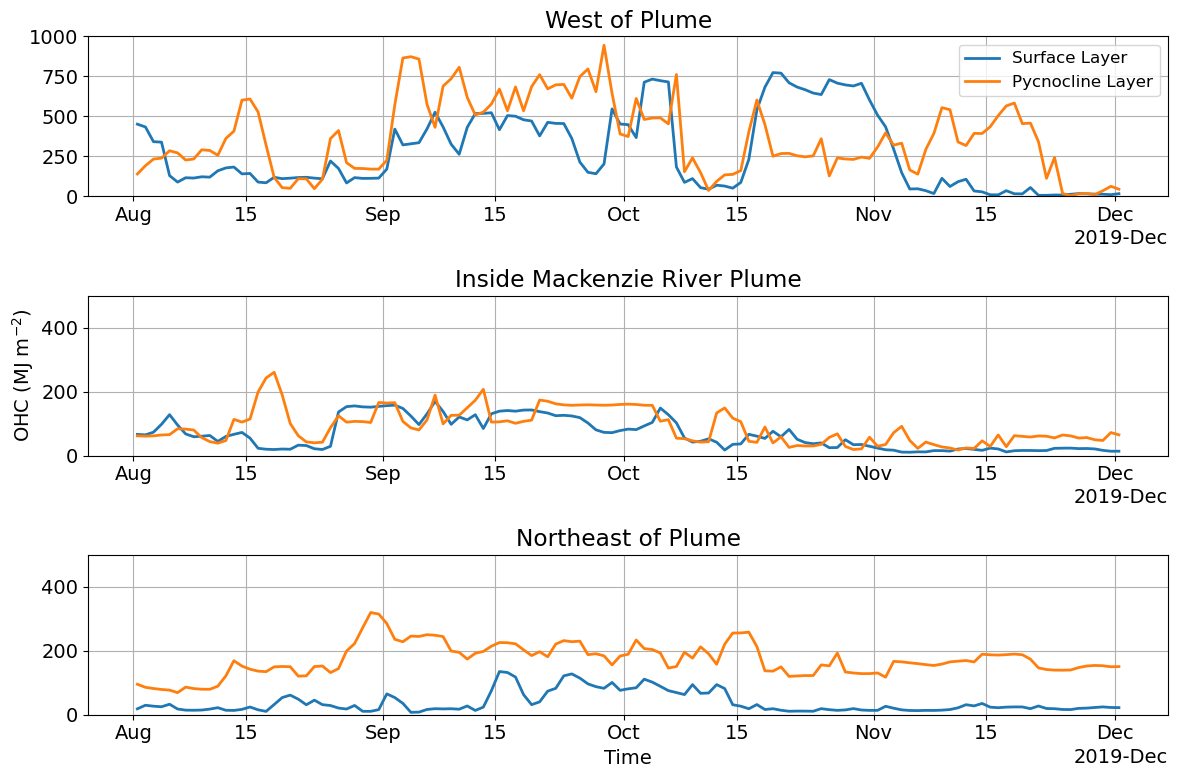

In [102]:
plt.rcParams['font.size'] = 14

# Create a figure with 3 rows, shared x-axis
fig, axes = plt.subplots(nrows=3, figsize=(12, 8))

# Data and titles for each subplot
ohc_data = [
    (ohc_SL_west, ohc_PC_west, "West of Plume"),
    (ohc_SL_plume, ohc_PC_plume, "Inside Mackenzie River Plume"),
    (ohc_SL_east, ohc_PC_east, "Northeast of Plume")
]

# Colors for consistency
colors = ['tab:blue', 'tab:orange']

# Plot each dataset in a loop
for ax, (ohc_SL, ohc_PC, title) in zip(axes, ohc_data):
    (ohc_SL / 1e6).plot(ax=ax, label='Surface Layer', color='tab:blue', linewidth=2)
    (ohc_PC / 1e6).plot(ax=ax, label='Pycnocline Layer', color='tab:orange', linewidth=2)
    ax.set_xlabel("")
    ax.set_title(title)
    ax.grid()

axes[1].set_ylabel("OHC (MJ m$^{-2}$)")
axes[0].set_ylim(0,1000)
axes[1].set_ylim(0,500)
axes[2].set_ylim(0,500)

# Add legend only to the top subplot
axes[0].legend(loc='upper right', fontsize=12)

# Set shared x-label
axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

#### What about full time series

Calculate OHC for a given grid cell

In [103]:
grid_volume = HH_grid.rAc * HH_grid.drF * HH_grid.hFacC
cell_thickness = HH_grid.drF

In [104]:
i_west=540
j_west=250

i_plume=565
j_plume=180

i_east=660
j_east=120

In [105]:
salt_pt_west = SALT_zarr_day.SALT.isel(i=i_west,j=j_west)
theta_pt_west = THETA_zarr_day.THETA.isel(i=i_west,j=j_west)
density_pt_west = RHOAnoma_zarr_day.RHOAnoma.isel(i=i_west,j=j_west) + rhoConst
vol_pt_west = grid_volume.isel(i=i_west, j=j_west)

In [106]:
salt_pt_plume = SALT_zarr_day.SALT.isel(i=i_plume,j=j_plume)
theta_pt_plume = THETA_zarr_day.THETA.isel(i=i_plume,j=j_plume)
density_pt_plume = RHOAnoma_zarr_day.RHOAnoma.isel(i=i_plume,j=j_plume) + rhoConst
vol_pt_plume = grid_volume.isel(i=i_plume, j=j_plume)

In [107]:
salt_pt_east = SALT_zarr_day.SALT.isel(i=i_east,j=j_east)
theta_pt_east = THETA_zarr_day.THETA.isel(i=i_east,j=j_east)
density_pt_east = RHOAnoma_zarr_day.RHOAnoma.isel(i=i_east,j=j_east) + rhoConst
vol_pt_east = grid_volume.isel(i=i_east, j=j_east)

In [108]:
# create masks of density layers
SL_mask_west, PC_mask_west, DW_mask_west = compute_density_masks(density_pt_west, vol_pt_west, upper_k=slice(0, 5), deep_k=slice(14, 17))
SL_mask_plume, PC_mask_plume, DW_mask_plume = compute_density_masks(density_pt_plume, vol_pt_plume, upper_k=slice(0, 5), deep_k=slice(14, 17))
SL_mask_east, PC_mask_east, DW_mask_east = compute_density_masks(density_pt_east, vol_pt_east, upper_k=slice(0, 5), deep_k=slice(14, 17))

In [109]:
# calculate OHC
ohc_SL_west = calculate_ohc(theta_pt_west, salt_pt_west, density_pt_west, cell_thickness, SL_mask_west)
ohc_PC_west = calculate_ohc(theta_pt_west, salt_pt_west, density_pt_west, cell_thickness, PC_mask_west)

ohc_SL_plume = calculate_ohc(theta_pt_plume, salt_pt_plume, density_pt_plume, cell_thickness, SL_mask_plume)
ohc_PC_plume = calculate_ohc(theta_pt_plume, salt_pt_plume, density_pt_plume, cell_thickness, PC_mask_plume)

ohc_SL_east = calculate_ohc(theta_pt_east, salt_pt_east, density_pt_east, cell_thickness, SL_mask_east)
ohc_PC_east = calculate_ohc(theta_pt_east, salt_pt_east, density_pt_east, cell_thickness, PC_mask_east)

In [112]:
def compute_monthly_avg_std(ohc_SL, ohc_PC):
    # compute monthly mean and std for surface layer and pycnocline layer
    # divide by 1e6 because we want MJ not Joules

    # surface layer
    ohc_SL_monthly_avg = ohc_SL.resample(time='1ME').mean() / 1e6
    ohc_SL_monthly_std = ohc_SL.resample(time='1ME').std() / 1e6
    # pycnocline layer
    ohc_PC_monthly_avg = ohc_PC.resample(time='1ME').mean() / 1e6
    ohc_PC_monthly_std = ohc_PC.resample(time='1ME').std() / 1e6

    return ohc_SL_monthly_avg, ohc_SL_monthly_std, ohc_PC_monthly_avg, ohc_PC_monthly_std

In [113]:
# compute monthly mean and std
ohc_SL_west_1M_avg, ohc_SL_west_1M__std, ohc_PC_west_1M__avg, ohc_PC_west_1M__std = compute_monthly_avg_std(ohc_SL_west, ohc_PC_west)
ohc_SL_plume_1M_avg, ohc_SL_plume_1M__std, ohc_PC_plume_1M__avg, ohc_PC_plume_1M__std = compute_monthly_avg_std(ohc_SL_plume, ohc_PC_plume)
ohc_SL_east_1M_avg, ohc_SL_east_1M__std, ohc_PC_east_1M__avg, ohc_PC_east_1M__std = compute_monthly_avg_std(ohc_SL_east, ohc_PC_east)

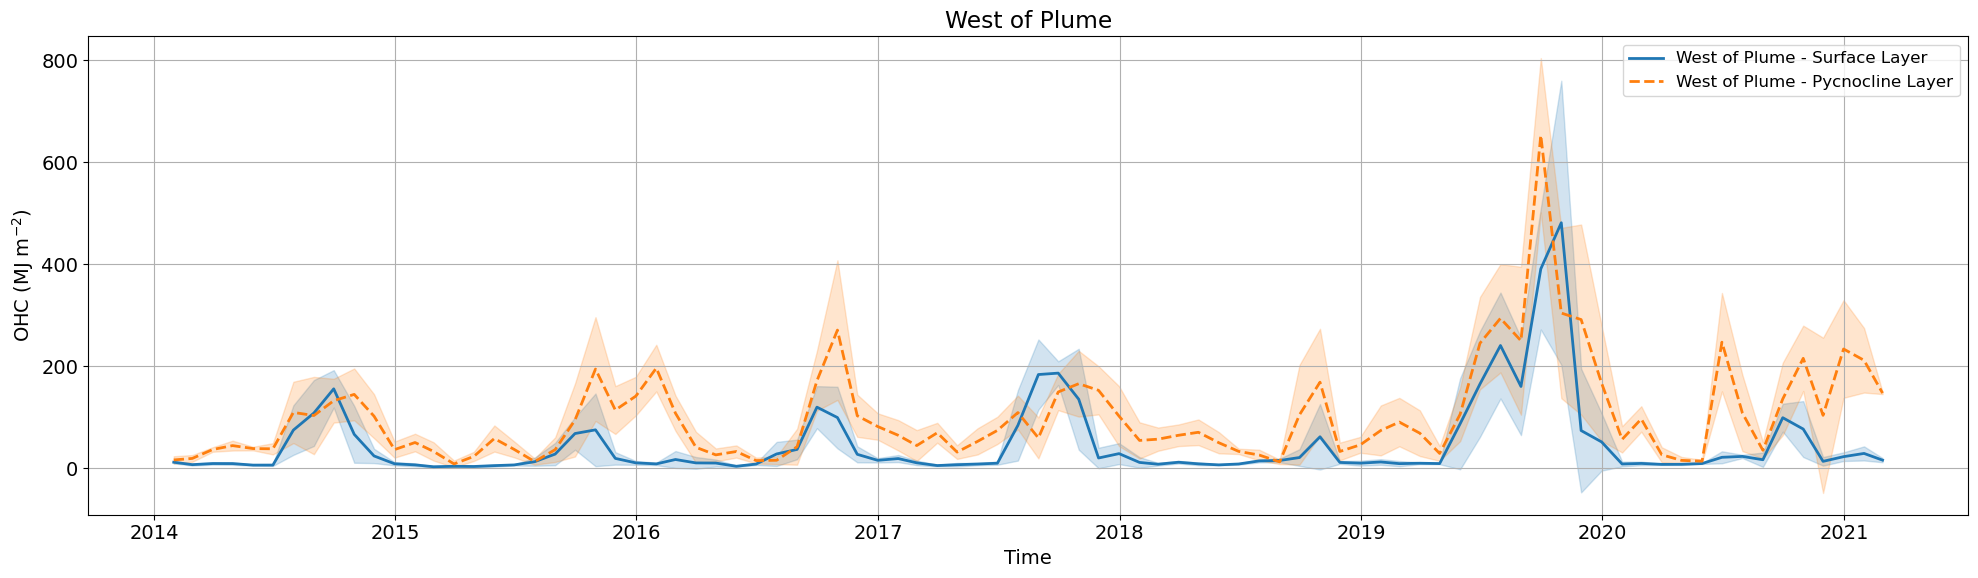

In [117]:
plt.rcParams['font.size'] = 14

# Create a figure
fig, ax = plt.subplots(figsize=(20, 6))

# Data and labels for each region
ohcs = [(ohc_SL_west_1M_avg, ohc_SL_west_1M__std, ohc_PC_west_1M__avg, ohc_PC_west_1M__std, "West of Plume")]

# Colors for consistency
colors = ['tab:blue', 'tab:orange']

# Loop through datasets and plot them
for (ohc_SL_avg, ohc_SL_std, ohc_PC_avg, ohc_PC_std, label), color in zip(ohcs, colors):
    ax.plot(ohc_SL_avg.time, ohc_SL_avg, label=f'{label} - Surface Layer', color=colors[0], linewidth=2)
    ax.plot(ohc_PC_avg.time, ohc_PC_avg, linestyle='dashed', label=f'{label} - Pycnocline Layer', color=colors[1], linewidth=2)
    
    # Add shading for +/- 1 std deviation
    ax.fill_between(ohc_SL_avg.time, 
                    ohc_SL_avg - ohc_SL_std, 
                    ohc_SL_avg + ohc_SL_std, 
                    color=colors[0], alpha=0.2)
    
    ax.fill_between(ohc_PC_avg.time, 
                    ohc_PC_avg - ohc_PC_std, 
                    ohc_PC_avg + ohc_PC_std, 
                    color=colors[1], alpha=0.2)

# Labels and legend
ax.set_ylabel("OHC (MJ m$^{-2}$)")
ax.set_xlabel("Time")
# ax.set_ylim(0, 1)
ax.set_title("West of Plume")
ax.legend(loc='upper right', fontsize=12)
ax.grid()

plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams['font.size'] = 14

# Create a figure with 3 rows, shared x-axis
fig, axes = plt.subplots(nrows=3, figsize=(20, 8), sharex=True)

# Data and titles for each subplot
ohc_data = [
    (ohc_SL_west, ohc_PC_west, "West of Plume"),
    (ohc_SL_plume, ohc_PC_plume, "Inside Mackenzie River Plume"),
    (ohc_SL_east, ohc_PC_east, "Northeast of Plume")
]

# Colors for consistency
colors = ['tab:blue', 'tab:orange']

# Loop through subplots
for ax, (ohc_SL, ohc_PC, title) in zip(axes, ohc_data):

    # Plot monthly mean
    ax.plot(ohc_SL_monthly_mean.time, ohc_SL_monthly_mean, label='Surface Layer', color=colors[0], linewidth=2)
    ax.plot(ohc_PC_monthly_mean.time, ohc_PC_monthly_mean, label='Pycnocline Layer', color=colors[1], linewidth=2)

    # Add shading for +/- 1 std deviation
    ax.fill_between(ohc_SL_monthly_mean.time, 
                    ohc_SL_monthly_mean - ohc_SL_monthly_std, 
                    ohc_SL_monthly_mean + ohc_SL_monthly_std, 
                    color=colors[0], alpha=0.2)

    ax.fill_between(ohc_PC_monthly_mean.time, 
                    ohc_PC_monthly_mean - ohc_PC_monthly_std, 
                    ohc_PC_monthly_mean + ohc_PC_monthly_std, 
                    color=colors[1], alpha=0.2)

    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid()

# Label the middle subplot
axes[1].set_ylabel("OHC (GJ m$^{-2}$)")

# Add legend only to the top subplot
axes[0].legend(loc='upper right', fontsize=12)

# Set shared x-label
axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

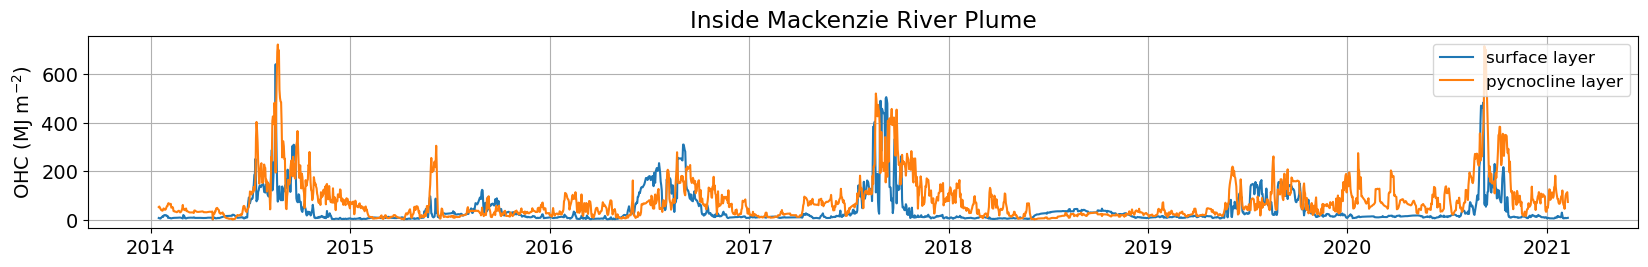

In [261]:
plt.rcParams['font.size'] = 14
(ohc_SL/1e6).plot(figsize=[20,2.5],label='surface layer')
(ohc_PC/1e6).plot(label='pycnocline layer')
plt.legend(loc='upper right',fontsize=12)
plt.title("Inside Mackenzie River Plume")
plt.xlabel("")
plt.grid()
# plt.ylabel("OHC relative to\nfreezing point (MJ m$^{-2}$)");
plt.ylabel("OHC (MJ m$^{-2}$)");

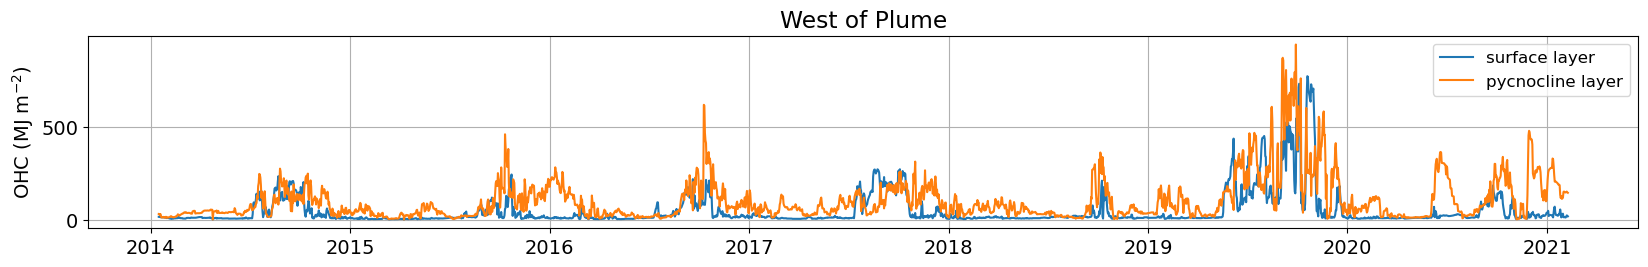

In [265]:
plt.rcParams['font.size'] = 14
(ohc_SL/1e6).plot(figsize=[20,2.5],label='surface layer')
(ohc_PC/1e6).plot(label='pycnocline layer')
plt.legend(loc='upper right',fontsize=12)
plt.title("West of Plume")
plt.xlabel("")
plt.grid()
# plt.ylabel("OHC relative to\nfreezing point (MJ m$^{-2}$)");
plt.ylabel("OHC (MJ m$^{-2}$)");

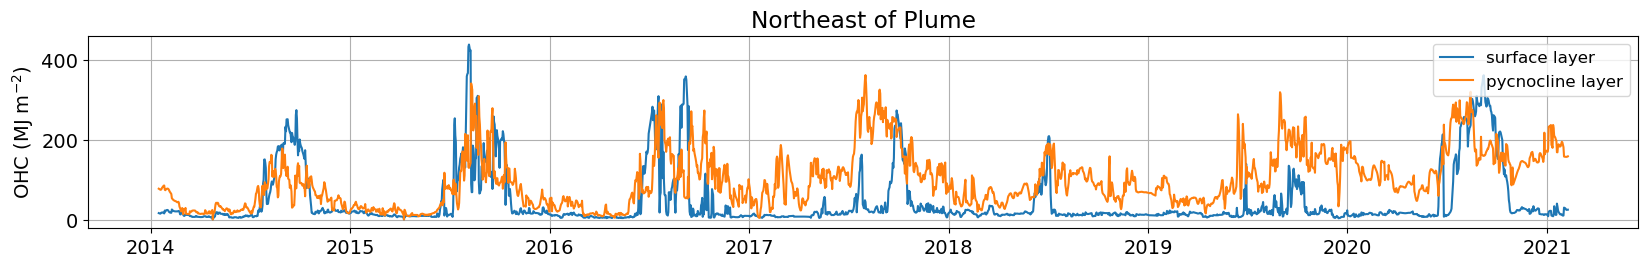

In [269]:
plt.rcParams['font.size'] = 14
(ohc_SL/1e6).plot(figsize=[20,2.5],label='surface layer')
(ohc_PC/1e6).plot(label='pycnocline layer')
plt.legend(loc='upper right',fontsize=12)
plt.title("Northeast of Plume")
plt.xlabel("")
plt.grid()
# plt.ylabel("OHC relative to\nfreezing point (MJ m$^{-2}$)");
plt.ylabel("OHC (MJ m$^{-2}$)");

### Calculate temperature deficit to freezing for a given salinity